7_1_1 jacobi

야코비 방법 수렴 완료: 607회 반복


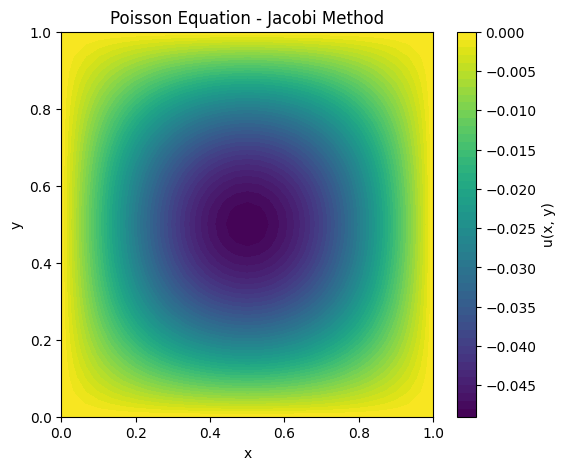

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 격자 및 조건 설정
N = 30  # 영역을 30등분 (격자점은 31x31개)
h = 1.0 / N
x = np.linspace(0, 1, N+1)
y = np.linspace(0, 1, N+1)
X, Y = np.meshgrid(x, y)

# 소스 항 f(x, y) 계산
F = np.sin(np.pi * X) * np.sin(np.pi * Y)

# 초기 추정값 (모두 0으로 시작)
U = np.zeros((N+1, N+1))
U_new = np.zeros((N+1, N+1))

# 2. 야코비 반복 계산 (Iterative Solver)
max_iterations = 5000  # 최대 반복 횟수
tolerance = 1e-5       # 수렴 기준 (이보다 적게 변하면 멈춤)

for k in range(max_iterations):
    # 내부 격자점(1~N-1)에 대해서만 업데이트 (테두리 0, N은 경계조건 0으로 유지)
    for i in range(1, N):
        for j in range(1, N):
            U_new[i, j] = 0.25 * (U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1] - (h**2) * F[i, j])
            
    # 수렴 판정 (가장 많이 변한 값이 tolerance보다 작으면 완료)
    max_diff = np.max(np.abs(U_new - U))
    if max_diff < tolerance:
        print(f"야코비 방법 수렴 완료: {k+1}회 반복")
        break
        
    # 다음 반복을 위해 배열 업데이트 (U_new를 U로 덮어쓰기)
    U = np.copy(U_new)

# 3. 결과 시각화 (등고선 그래프)
plt.figure(figsize=(6, 5))
plt.contourf(X, Y, U, levels=50, cmap='viridis')
plt.colorbar(label='u(x, y)')
plt.title('Poisson Equation - Jacobi Method')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

7_1_1 gauss-seidal

2) 가우스-자이델 방법 수렴: 367회 반복


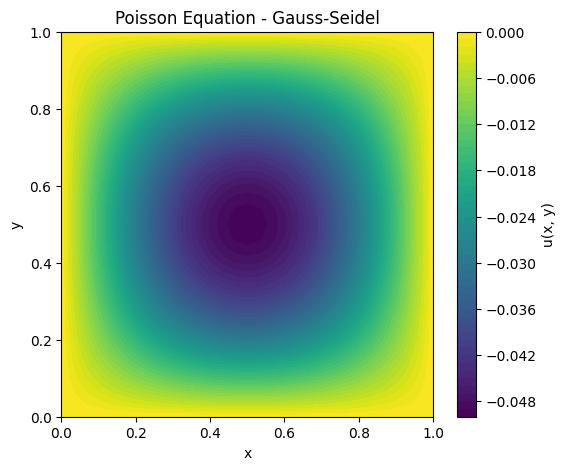

In [13]:
U_gs = np.zeros((N+1, N+1))
iter_gs = 0

for k in range(max_iterations):
    max_diff = 0.0 # 변화량을 측정하기 위한 변수
    for i in range(1, N):
        for j in range(1, N):
            old_val = U_gs[i, j] # 업데이트 전 과거 값 저장
            
            # 배열 하나(U_gs)에 최신 값을 즉시 덮어씀 (왼쪽, 아래쪽은 이미 최신 값임)
            U_gs[i, j] = 0.25 * (U_gs[i+1, j] + U_gs[i-1, j] + U_gs[i, j+1] + U_gs[i, j-1] - (h**2) * F[i, j])
            
            # 가장 크게 변한 차이값 갱신
            diff = abs(U_gs[i, j] - old_val)
            if diff > max_diff:
                max_diff = diff
                
    if max_diff < tolerance:
        iter_gs = k + 1
        break

print(f"2) 가우스-자이델 방법 수렴: {iter_gs}회 반복")

plt.figure(figsize=(6, 5))
plt.contourf(X, Y, U_gs, levels=50, cmap='viridis') 
plt.colorbar(label='u(x, y)')
plt.title('Poisson Equation - Gauss-Seidel') 
plt.xlabel('x')
plt.ylabel('y')
plt.show()

7_1_1 gauss-seidal sor

3) SOR 방법 수렴 (w=1.85): 61회 반복


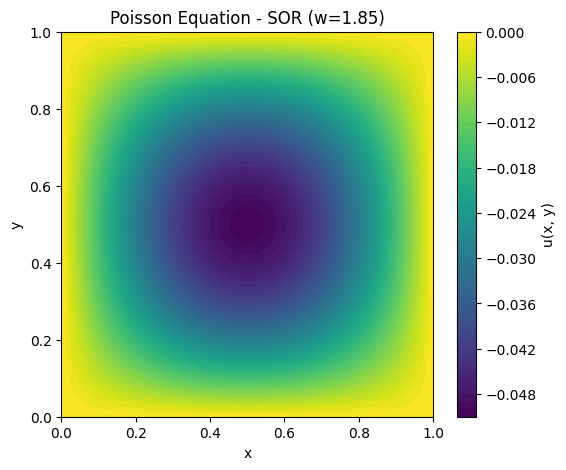

In [22]:
U_gs = np.zeros((N+1, N+1))
iter_gs = 0
w=1.85

for k in range(max_iterations):
    max_diff = 0.0 # 변화량을 측정하기 위한 변수
    for i in range(1, N):
        for j in range(1, N):
            old_val = U_gs[i, j] # 업데이트 전 과거 값 저장
            
            # 배열 하나(U_gs)에 최신 값을 즉시 덮어씀 (왼쪽, 아래쪽은 이미 최신 값임)
            U_gs[i, j] = (1-w)*U_gs[i,j]+w/4*(U_gs[i+1, j] + U_gs[i-1, j] + U_gs[i, j+1] + U_gs[i, j-1] - (h**2) * F[i, j])
            
            # 가장 크게 변한 차이값 갱신
            diff = abs(U_gs[i, j] - old_val)
            if diff > max_diff:
                max_diff = diff
                
    if max_diff < tolerance:
        iter_gs = k + 1
        break

print(f"3) SOR 방법 수렴 (w={w}): {iter_gs}회 반복")

plt.figure(figsize=(6, 5))
plt.contourf(X, Y, U_gs, levels=50, cmap='viridis') 
plt.colorbar(label='u(x, y)')
plt.title(f'Poisson Equation - SOR (w={w})')  
plt.xlabel('x')
plt.ylabel('y')
plt.show()

7_1_2

1) Jacobi      :  607회 반복, 0.5238초 소요, Error = 1.770711e-03
2) Gauss-Seidel:  367회 반복, 0.4417초 소요, Error = 8.569251e-04
3) SOR (w=1.85) :   61회 반복, 0.0858초 소요, Error = 4.330546e-05


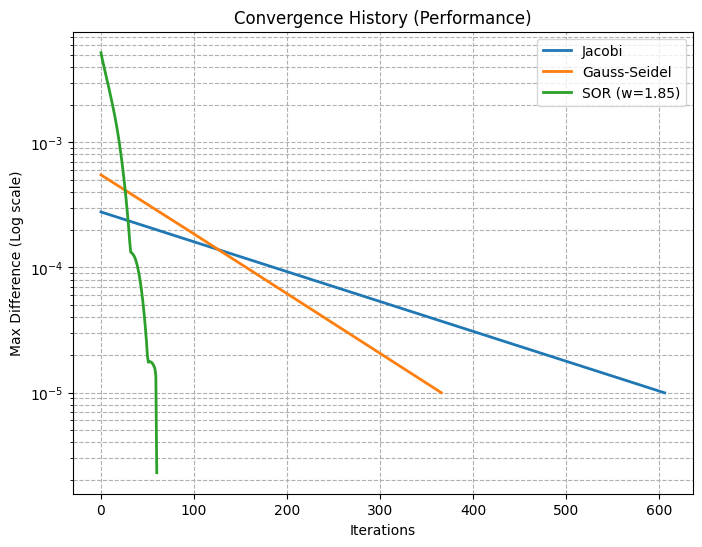

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. 설정 및 해석해
N = 30
h = 1.0 / N
x = np.linspace(0, 1, N+1)
y = np.linspace(0, 1, N+1)
X, Y = np.meshgrid(x, y)
F = np.sin(np.pi * X) * np.sin(np.pi * Y)

# 해석해 (Exact Solution) : 수학적 정답
U_exact = -(1.0 / (2.0 * np.pi**2)) * np.sin(np.pi * X) * np.sin(np.pi * Y)

max_iterations = 10000
tolerance = 1e-5

# ----------------------------------------------------
# 1) Jacobi Method
# ----------------------------------------------------
U_jacobi = np.zeros((N+1, N+1))
U_new = np.zeros((N+1, N+1))
hist_jacobi = []  # 수렴 기록 저장용 배열

start_time = time.time()
for k in range(max_iterations):
    for i in range(1, N):
        for j in range(1, N):
            U_new[i, j] = 0.25 * (U_jacobi[i+1, j] + U_jacobi[i-1, j] + U_jacobi[i, j+1] + U_jacobi[i, j-1] - (h**2) * F[i, j])
            
    max_diff = np.max(np.abs(U_new - U_jacobi))
    hist_jacobi.append(max_diff)
    if max_diff < tolerance:
        break
    U_jacobi = np.copy(U_new)
time_jacobi = time.time() - start_time
error_jacobi = np.max(np.abs(U_jacobi - U_exact)) # 해석해와의 오차 측정

# ----------------------------------------------------
# 2) Gauss-Seidel Method
# ----------------------------------------------------
U_gs = np.zeros((N+1, N+1))
hist_gs = []

start_time = time.time()
for k in range(max_iterations):
    max_diff = 0.0
    for i in range(1, N):
        for j in range(1, N):
            old_val = U_gs[i, j]
            U_gs[i, j] = 0.25 * (U_gs[i+1, j] + U_gs[i-1, j] + U_gs[i, j+1] + U_gs[i, j-1] - (h**2) * F[i, j])
            diff = abs(U_gs[i, j] - old_val)
            if diff > max_diff:
                max_diff = diff
    hist_gs.append(max_diff)
    if max_diff < tolerance:
        break
time_gs = time.time() - start_time
error_gs = np.max(np.abs(U_gs - U_exact))

# ----------------------------------------------------
# 3) SOR Method (w=1.85)
# ----------------------------------------------------
U_sor = np.zeros((N+1, N+1)) 
hist_sor = []              
w = 1.85

start_time = time.time()
for k in range(max_iterations):
    max_diff = 0.0
    for i in range(1, N):
        for j in range(1, N):
            old_val = U_sor[i, j] # 업데이트 전 과거 값 저장
            
            # 배열 하나(U_sor)에 최신 값을 즉시 덮어씀
            U_sor[i, j] = (1-w)*U_sor[i,j] + w/4*(U_sor[i+1, j] + U_sor[i-1, j] + U_sor[i, j+1] + U_sor[i, j-1] - (h**2) * F[i, j])
            
            # 가장 크게 변한 차이값 갱신
            diff = abs(U_sor[i, j] - old_val)
            if diff > max_diff:
                max_diff = diff
                
    hist_sor.append(max_diff) 
    
    if max_diff < tolerance:
        break

time_sor = time.time() - start_time
error_sor = np.max(np.abs(U_sor - U_exact)) 

# ==========================================
# 출력 및 성능 그래프 (Performance Graph)
# ==========================================
print(f"1) Jacobi      : {len(hist_jacobi):4d}회 반복, {time_jacobi:.4f}초 소요, Error = {error_jacobi:.6e}")
print(f"2) Gauss-Seidel: {len(hist_gs):4d}회 반복, {time_gs:.4f}초 소요, Error = {error_gs:.6e}")
print(f"3) SOR (w={w}) : {len(hist_sor):4d}회 반복, {time_sor:.4f}초 소요, Error = {error_sor:.6e}")

plt.figure(figsize=(8, 6))
plt.semilogy(hist_jacobi, label='Jacobi', linewidth=2)
plt.semilogy(hist_gs, label='Gauss-Seidel', linewidth=2)
plt.semilogy(hist_sor, label=f'SOR (w={w})', linewidth=2)

plt.xlabel('Iterations')
plt.ylabel('Max Difference (Log scale)')
plt.title('Convergence History (Performance)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

7_2_1

SOR 방법 수렴 완료: 108회 반복


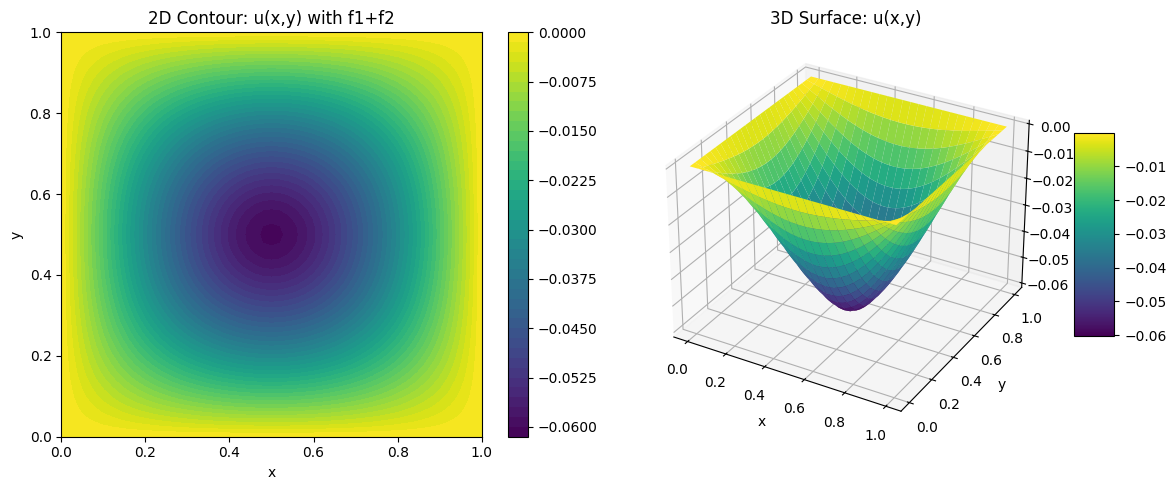

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 격자 및 조건 설정 (가우시안 피크를 잘 보기 위해 50등분으로 늘림)
N = 50  
h = 1.0 / N
x = np.linspace(0, 1, N+1)
y = np.linspace(0, 1, N+1)
X, Y = np.meshgrid(x, y)

# 2. 소스 항(Forcing functions) 계산
# f1: 부드러운 사인 파형
F1 = np.sin(np.pi * X) * np.sin(np.pi * Y)
# f2: 중앙(0.5, 0.5)에 집중된 가우시안 파형
F2 = np.exp(-100.0 * ((X - 0.5)**2 + (Y - 0.5)**2))

# 전체 소스 항 (선형 결합)
F = F1 + F2

# 3. SOR 반복 계산 초기화
U_sor = np.zeros((N+1, N+1))
max_iterations = 10000
tolerance = 1e-5
w = 1.85  # 최적의 가속 계수에 가까운 값
iter_sor = 0

# 4. SOR 계산 수행
for k in range(max_iterations):
    max_diff = 0.0
    for i in range(1, N):
        for j in range(1, N):
            old_val = U_sor[i, j]
            
            # SOR 업데이트 식 적용 (우변에 F = F1 + F2가 들어감)
            U_sor[i, j] = (1 - w) * old_val + (w / 4) * (U_sor[i+1, j] + U_sor[i-1, j] + U_sor[i, j+1] + U_sor[i, j-1] - (h**2) * F[i, j])
            
            diff = abs(U_sor[i, j] - old_val)
            if diff > max_diff:
                max_diff = diff
                
    if max_diff < tolerance:
        iter_sor = k + 1
        break

print(f"SOR 방법 수렴 완료: {iter_sor}회 반복")

# 5. 결과 시각화 (등고선 및 3D 그래프)
fig = plt.figure(figsize=(12, 5))

# 2D 등고선 그래프
ax1 = fig.add_subplot(1, 2, 1)
contour = ax1.contourf(X, Y, U_sor, levels=50, cmap='viridis')
fig.colorbar(contour, ax=ax1)
ax1.set_title('2D Contour: u(x,y) with f1+f2')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# 3D 표면 그래프 (볼록한 형태를 직관적으로 보기 위해 추가)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X, Y, U_sor, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)
ax2.set_title('3D Surface: u(x,y)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
plt.show()

7_2_2

f2만 고려한 SOR 방법 수렴 완료: 69회 반복


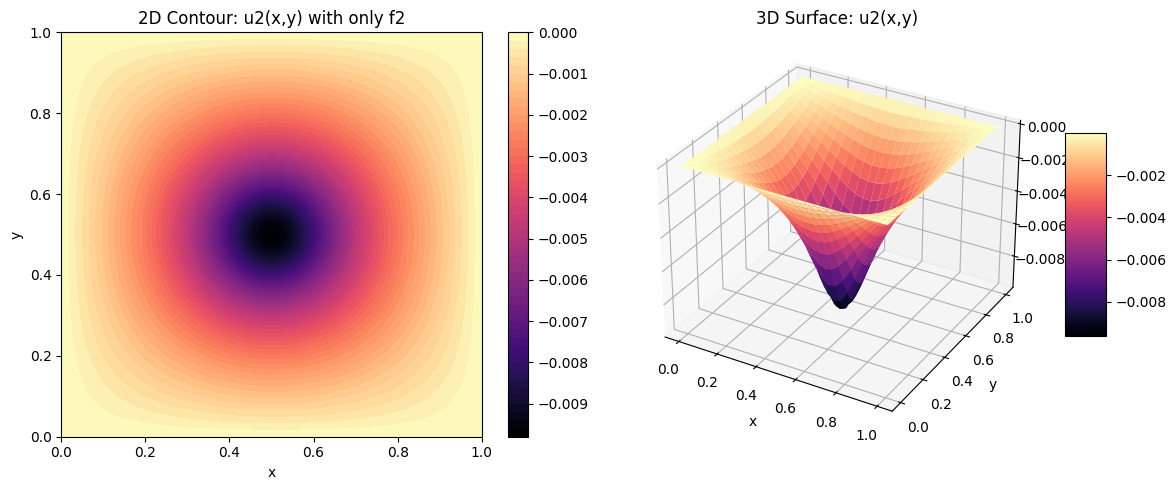

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 격자 및 조건 설정
N = 50  # 뾰족한 가우시안 분포를 잘 잡기 위해 50등분 유지
h = 1.0 / N
x = np.linspace(0, 1, N+1)
y = np.linspace(0, 1, N+1)
X, Y = np.meshgrid(x, y)

# 2. 소스 항 계산 (오직 f2만 사용!)
# f2: 중앙(0.5, 0.5)에 아주 강하게 집중된 가우시안 파형
F2 = np.exp(-100.0 * ((X - 0.5)**2 + (Y - 0.5)**2))

# 3. SOR 반복 계산 초기화 (이번엔 배열 이름을 U_sor2로 짓겠습니다)
U_sor2 = np.zeros((N+1, N+1))
max_iterations = 10000
tolerance = 1e-5
w = 1.85  # 가속 계수
iter_sor2 = 0

# 4. SOR 계산 수행
for k in range(max_iterations):
    max_diff = 0.0
    for i in range(1, N):
        for j in range(1, N):
            old_val = U_sor2[i, j]
            
            # SOR 업데이트 식 적용 (우변에 F2만 들어갑니다!)
            U_sor2[i, j] = (1 - w) * old_val + (w / 4) * (U_sor2[i+1, j] + U_sor2[i-1, j] + U_sor2[i, j+1] + U_sor2[i, j-1] - (h**2) * F2[i, j])
            
            diff = abs(U_sor2[i, j] - old_val)
            if diff > max_diff:
                max_diff = diff
                
    if max_diff < tolerance:
        iter_sor2 = k + 1
        break

print(f"f2만 고려한 SOR 방법 수렴 완료: {iter_sor2}회 반복")

# 5. 결과 시각화 (등고선 및 3D 그래프)
fig = plt.figure(figsize=(12, 5))

# 2D 등고선 그래프
ax1 = fig.add_subplot(1, 2, 1)
contour = ax1.contourf(X, Y, U_sor2, levels=50, cmap='magma')
fig.colorbar(contour, ax=ax1)
ax1.set_title('2D Contour: u2(x,y) with only f2')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# 3D 표면 그래프
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X, Y, U_sor2, cmap='magma', edgecolor='none')
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)
ax2.set_title('3D Surface: u2(x,y)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
plt.show()

7_2_3

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 공통 격자 설정 (N=50으로 통일)
N = 50  
h = 1.0 / N
x = np.linspace(0, 1, N+1)
y = np.linspace(0, 1, N+1)
X, Y = np.meshgrid(x, y)

# 2. 소스 항 정의
F1 = np.sin(np.pi * X) * np.sin(np.pi * Y)                           # 1번 문제의 f1
F2 = np.exp(-100.0 * ((X - 0.5)**2 + (Y - 0.5)**2))                  # 2-(2)번 문제의 f2
F_total = F1 + F2                                                    # 2-(1)번 문제의 전체 f

# 3. SOR 계산을 '함수'로 만들기 (코드 중복 방지)
def solve_poisson_sor(F, w=1.85, tol=1e-5, max_iter=10000):
    U = np.zeros((N+1, N+1))
    for k in range(max_iter):
        max_diff = 0.0
        for i in range(1, N):
            for j in range(1, N):
                old_val = U[i, j]
                U[i, j] = (1 - w)*old_val + (w/4)*(U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1] - (h**2)*F[i, j])
                diff = abs(U[i, j] - old_val)
                if diff > max_diff:
                    max_diff = diff
        if max_diff < tol:
            break
    return U

# 4. 각각의 해 구하기 (여기서 U_sor1이 탄생합니다!)
print("계산 중...")
U_sor1 = solve_poisson_sor(F1)          # u1 계산
U_sor2 = solve_poisson_sor(F2)          # u2 계산
U_sor_total = solve_poisson_sor(F_total) # 전체 u 계산

# 5. 선형성(Linearity) 검증: U_total 과 (U1 + U2) 의 차이 계산
U_sum = U_sor1 + U_sor2
max_error = np.max(np.abs(U_sor_total - U_sum))

print("-" * 40)
print(f"전체 해(U)와 합쳐진 해(U1+U2)의 최대 오차: {max_error:.5e}")
if max_error < 1e-4:
    print("결론: u = u1 + u2 가 완벽하게 성립합니다! (선형성 증명 완료)")
print("-" * 40)

계산 중...
----------------------------------------
전체 해(U)와 합쳐진 해(U1+U2)의 최대 오차: 1.62385e-04
----------------------------------------
